# 05 — Superresolution: coarse solves, fine fields

The pattern of PhysicsNeMo's turbulent super-resolution example, on Kratos meshes:
solve (here: evaluate analytically) on a **coarse** mesh, sample onto a low-res voxel
grid, let `physicsnemo.models.srrn.SRResNet` upscale it, and scatter the fine grid
onto a **fine** mesh's nodes.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo   # optional runtime dependencies of the application
> ```
>
> Everything below runs on CPU in under a minute; outputs are written to `./output/`.

In [1]:
import math
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication import grid_bridge
from KratosMultiphysics.PhysicsNeMoApplication import superresolution_process
from physicsnemo.models.srrn import SRResNet

torch.manual_seed(0)
numpy.random.seed(0)
Path("output").mkdir(exist_ok=True)

## Coarse and fine meshes

Structured tetrahedral meshes of the unit cube (each hex cell split into 6 tets — the
same decomposition the mesh bridge uses).

In [2]:
_HEX_TO_TETS = ((0, 1, 2, 6), (0, 2, 3, 6), (0, 3, 7, 6), (0, 7, 4, 6), (0, 4, 5, 6), (0, 5, 1, 6))

def create_structured_tet_model_part(model, name, divisions, variables):
    model_part = model.CreateModelPart(name)
    for variable in variables:
        model_part.AddNodalSolutionStepVariable(variable)
    props = model_part.CreateNewProperties(1)
    n = divisions + 1
    node_id = 0
    for i in range(n):
        for j in range(n):
            for k in range(n):
                node_id += 1
                model_part.CreateNewNode(node_id, i / divisions, j / divisions, k / divisions)
    def nid(i, j, k):
        return i * n * n + j * n + k + 1
    element_id = 0
    for i in range(divisions):
        for j in range(divisions):
            for k in range(divisions):
                corners = [nid(i, j, k), nid(i+1, j, k), nid(i+1, j+1, k), nid(i, j+1, k),
                           nid(i, j, k+1), nid(i+1, j, k+1), nid(i+1, j+1, k+1), nid(i, j+1, k+1)]
                for tet in _HEX_TO_TETS:
                    element_id += 1
                    model_part.CreateNewElement("Element3D4N", element_id, [corners[c] for c in tet], props)
    return model_part

model = Kratos.Model()
coarse = create_structured_tet_model_part(model, "Coarse", 4, [Kratos.PRESSURE])
fine = create_structured_tet_model_part(model, "Fine", 12, [Kratos.PRESSURE, Kratos.TEMPERATURE])
print(f"coarse: {coarse.NumberOfNodes()} nodes, fine: {fine.NumberOfNodes()} nodes")

coarse: 125 nodes, fine: 2197 nodes


## Training data: a parametrized smooth field

`u(x; a, b) = sin(a·πx)·sin(b·πy)·z + x` evaluated on the coarse mesh (the "coarse
solve") and on the fine mesh (the ground truth). The grid bridge turns both into
voxel grids: coarse `8³`, fine `16³` — an SRResNet `scaling_factor=2` pair.

In [3]:
COARSE_SHAPE, FINE_SHAPE = (8, 8, 8), (16, 16, 16)

def field(x, y, z, a, b):
    return numpy.sin(a * numpy.pi * x) * numpy.sin(b * numpy.pi * y) * z + x

def set_field(model_part, variable, a, b):
    for node in model_part.Nodes:
        node.SetSolutionStepValue(variable, float(field(node.X, node.Y, node.Z, a, b)))

train_pairs = []
parameters = [(a, b) for a in (0.5, 1.0, 1.5) for b in (0.5, 1.0, 1.5)]
for a, b in parameters:
    set_field(coarse, Kratos.PRESSURE, a, b)
    set_field(fine, Kratos.PRESSURE, a, b)
    coarse_grid, box = grid_bridge.SampleFieldsOnGrid(
        coarse, [("PRESSURE", "node_historical")], COARSE_SHAPE)
    fine_grid, _ = grid_bridge.SampleFieldsOnGrid(
        fine, [("PRESSURE", "node_historical")], FINE_SHAPE, bounding_box=box)
    train_pairs.append((torch.from_numpy(coarse_grid).float(),
                        torch.from_numpy(fine_grid).float()))
print(len(train_pairs), "coarse/fine grid pairs")

9 coarse/fine grid pairs


## Training a small SRResNet

final loss: 0.0012457832926884294


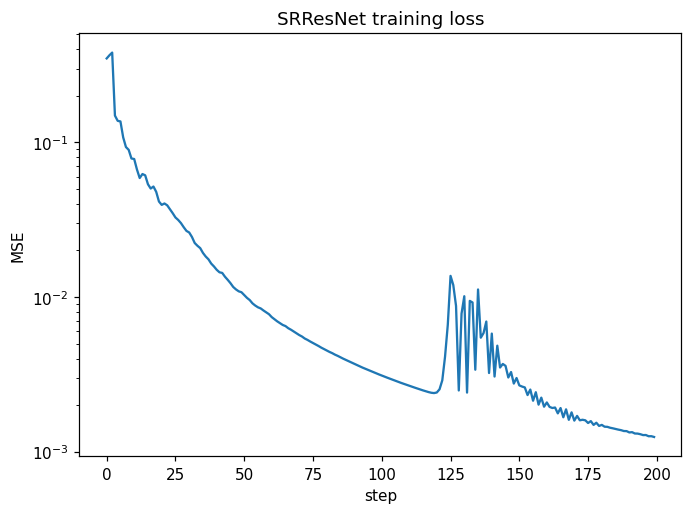

In [4]:
srresnet = SRResNet(in_channels=1, out_channels=1, conv_layer_size=8,
                    n_resid_blocks=2, scaling_factor=2)
optimizer = torch.optim.Adam(srresnet.parameters(), lr=2e-3)

inputs = torch.stack([pair[0] for pair in train_pairs])
targets = torch.stack([pair[1] for pair in train_pairs])

losses = []
for step in range(200):
    optimizer.zero_grad()
    loss = torch.nn.functional.mse_loss(srresnet(inputs), targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.semilogy(losses)
plt.xlabel("step"); plt.ylabel("MSE"); plt.title("SRResNet training loss")
plt.tight_layout(); plt.savefig("output/sr_loss.png", dpi=120); plt.show()
print("final loss:", losses[-1])
assert losses[-1] < 1e-2, f"training did not converge: final loss {losses[-1]:.3e}"

## Saving the checkpoint

`SRResNet` is a `physicsnemo.Module`, so it saves as a self-describing `.mdlus`
checkpoint — loadable by `model_registry.LoadModel` with
`"checkpoint_type": "physicsnemo"`.

In [5]:
srresnet.save("output/srresnet.mdlus")
print("saved output/srresnet.mdlus")

saved output/srresnet.mdlus


## Deploying with SuperResolutionProcess

An **unseen** parameter pair: the coarse mesh carries the "solve", and the process
writes the superresolved field into `TEMPERATURE` on the fine mesh.

In [6]:
a_test, b_test = 1.25, 0.75  # not in the training set
set_field(coarse, Kratos.PRESSURE, a_test, b_test)

settings = Kratos.Parameters("""{
    "Parameters": {
        "coarse_model_part_name" : "Coarse",
        "fine_model_part_name"   : "Fine",
        "model_settings"         : {
            "checkpoint_file" : "output/srresnet.mdlus",
            "checkpoint_type" : "physicsnemo",
            "device"          : "auto"
        },
        "input_fields"           : [ { "variable_name" : "PRESSURE",    "data_location" : "node_historical" } ],
        "output_fields"          : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_historical" } ],
        "coarse_grid_shape"      : [8, 8, 8],
        "output_interval"        : 1
    }
}""")
process = superresolution_process.Factory(settings, model)
coarse.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()

predicted = numpy.array([node.GetSolutionStepValue(Kratos.TEMPERATURE) for node in fine.Nodes])
exact = numpy.array([field(node.X, node.Y, node.Z, a_test, b_test) for node in fine.Nodes])
rmse = float(numpy.sqrt(numpy.mean((predicted - exact) ** 2)))
print(f"fine-mesh RMSE at unseen (a, b) = ({a_test}, {b_test}): {rmse:.4f}")
assert rmse < 0.15, f"superresolution does not generalize: RMSE {rmse:.3e}"

fine-mesh RMSE at unseen (a, b) = (1.25, 0.75): 0.0323


## Slice comparison

A `z = 0.5` slice: the coarse input, the superresolved prediction on the fine mesh,
and the exact field.

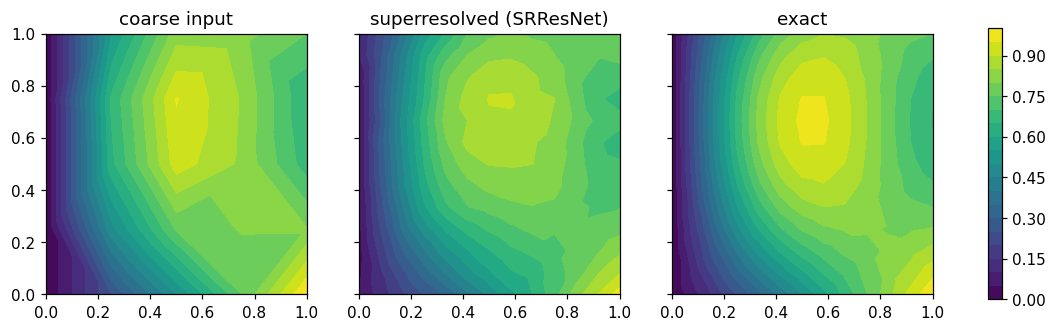

In [7]:
def slice_values(model_part, values_by_node_index, z_target=0.5, tol=1e-6):
    xs, ys, vs = [], [], []
    for index, node in enumerate(model_part.Nodes):
        if abs(node.Z - z_target) < tol:
            xs.append(node.X); ys.append(node.Y); vs.append(values_by_node_index[index])
    return numpy.array(xs), numpy.array(ys), numpy.array(vs)

coarse_values = numpy.array([node.GetSolutionStepValue(Kratos.PRESSURE) for node in coarse.Nodes])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (part, values, title) in zip(axes, [
        (coarse, coarse_values, "coarse input"),
        (fine, predicted, "superresolved (SRResNet)"),
        (fine, exact, "exact")]):
    xs, ys, vs = slice_values(part, values)
    im = ax.tricontourf(xs, ys, vs, levels=20)
    ax.set_title(title); ax.set_aspect("equal")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.savefig("output/sr_slices.png", dpi=120, bbox_inches="tight")
plt.show()

## Where to go from here

- Replace the analytic field with actual coarse/fine Kratos solves of your problem
  (export training pairs with `grid_bridge.SampleFieldsOnGrid` inside your analysis,
  or via `DatasetExportProcess`/`MeshExportProcess`).
- Quantify quality against a reference fine solve with `ValidationMetricsProcess`.
- Scale `coarse_grid_shape`, `scaling_factor` (2/4/8) and the network size to your
  resolution gap; move training to GPU by dropping the `"device": "cpu"` overrides.